In [1]:
import numpy as np
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import pandas as pd
df1 = pd.read_csv("tlsn_native.csv", header=0)
df2 = pd.read_csv("tlsn_browser.csv", header=0)
#df3 = pd.read_csv("tlsn_native12.csv", header=0)

In [17]:
df_reclaim = pd.read_csv("reclaim_TLS1_3_Gnark.csv", header=0)


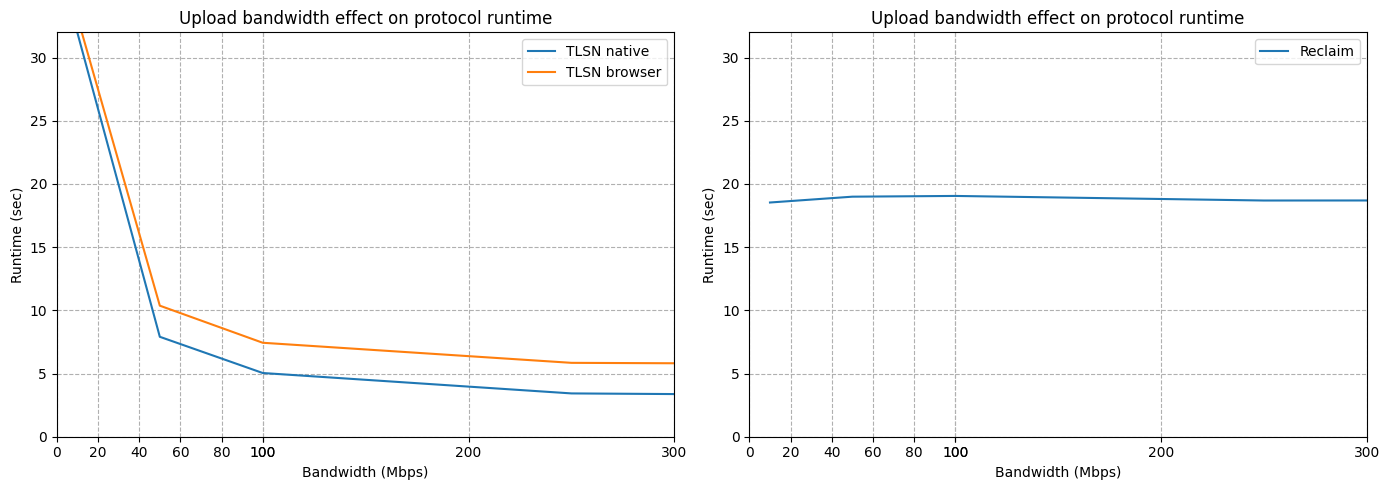

In [15]:
plt.style.use("default")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

df1_filter = df1[df1["group"] == "bandwidth"].copy()
df2_filter = df2[df2["group"] == "bandwidth"].copy()
df3_filter = df_reclaim[df_reclaim["group"] == "bandwidth"].copy()

agg1 = df1_filter.groupby("bandwidth")["time_total"].mean().reset_index()
agg2 = df2_filter.groupby("bandwidth")["time_total"].mean().reset_index()
agg3 = df3_filter.groupby("bandwidth(Mbps)")["runtime(ms)"].mean().reset_index()

ax1.plot(agg1["bandwidth"], agg1["time_total"]/1000.0, label="TLSN native")
ax1.plot(agg2["bandwidth"], agg2["time_total"]/1000.0, label="TLSN browser")
ax2.plot(agg3["bandwidth(Mbps)"], agg3["runtime(ms)"]/1000.0, label="Reclaim")

for ax in [ax1, ax2]:
    ax.set_xlim(0, 300)
    ax.set_ylim(0, 32)
    ax.set_xlabel("Bandwidth (Mbps)")
    ax.set_ylabel("Runtime (sec)")
    ax.set_title("Upload bandwidth effect on protocol runtime")
    ax.legend(loc="upper right")
    ax.set_xticks(list(range(0, 120, 20)) + list(range(100, 400, 100)))
    ax.grid(True, linestyle="--")

plt.tight_layout()
plt.savefig("bandwidth.svg", bbox_inches="tight")
plt.show()

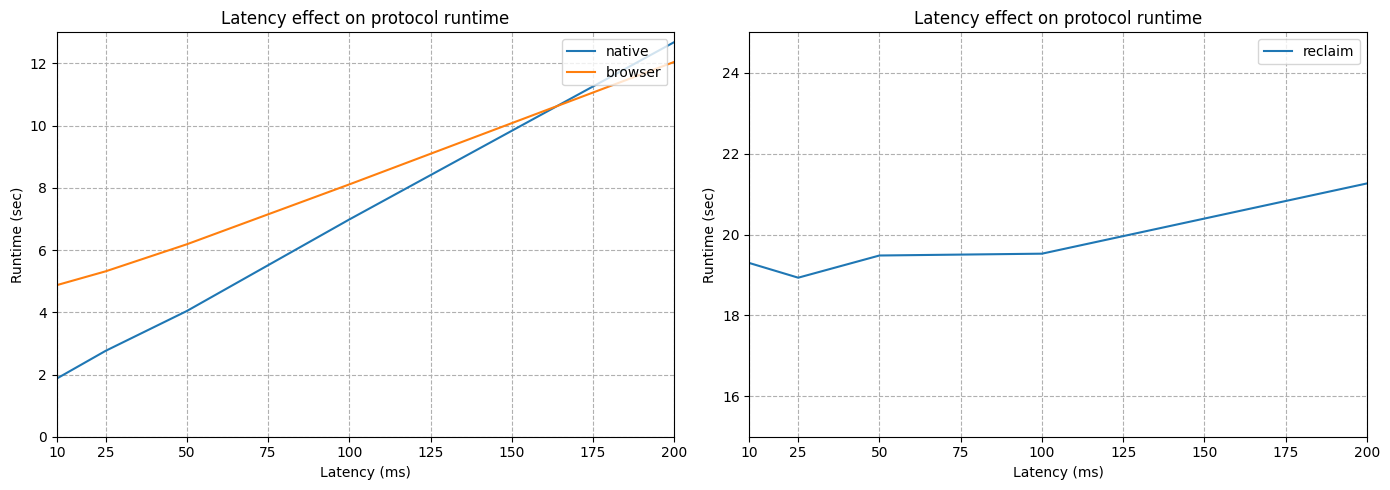

In [20]:
plt.style.use("default")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

df1_filter = df1[df1["group"] == "latency"].copy()
df2_filter = df2[df2["group"] == "latency"].copy()
df3_filter = df_reclaim[df_reclaim["group"] == "latency"].copy()

agg1 = df1_filter.groupby("latency")["time_total"].mean().reset_index()
agg2 = df2_filter.groupby("latency")["time_total"].mean().reset_index()
agg3 = df3_filter.groupby("latency(ms)")["runtime(ms)"].mean().reset_index()

ax1.plot(agg1["latency"], agg1["time_total"]/1000.0, label="native")
ax1.plot(agg2["latency"], agg2["time_total"]/1000.0, label="browser")
ax2.plot(agg3["latency(ms)"], agg3["runtime(ms)"]/1000.0, label="reclaim")

ax1.set_ylim(0, 13)
ax2.set_ylim(15, 25)

for ax in [ax1, ax2]:
    ax.set_xlim(10, 200)
    ax.set_xlabel("Latency (ms)")
    ax.set_ylabel("Runtime (sec)")
    ax.set_title("Latency effect on protocol runtime")
    ax.legend(loc="upper right")
    ax.set_xticks([10] + list(range(25, 201, 25)))
    ax.grid(True, linestyle="--")

plt.tight_layout()
plt.savefig("latency.svg", bbox_inches="tight")
plt.show()

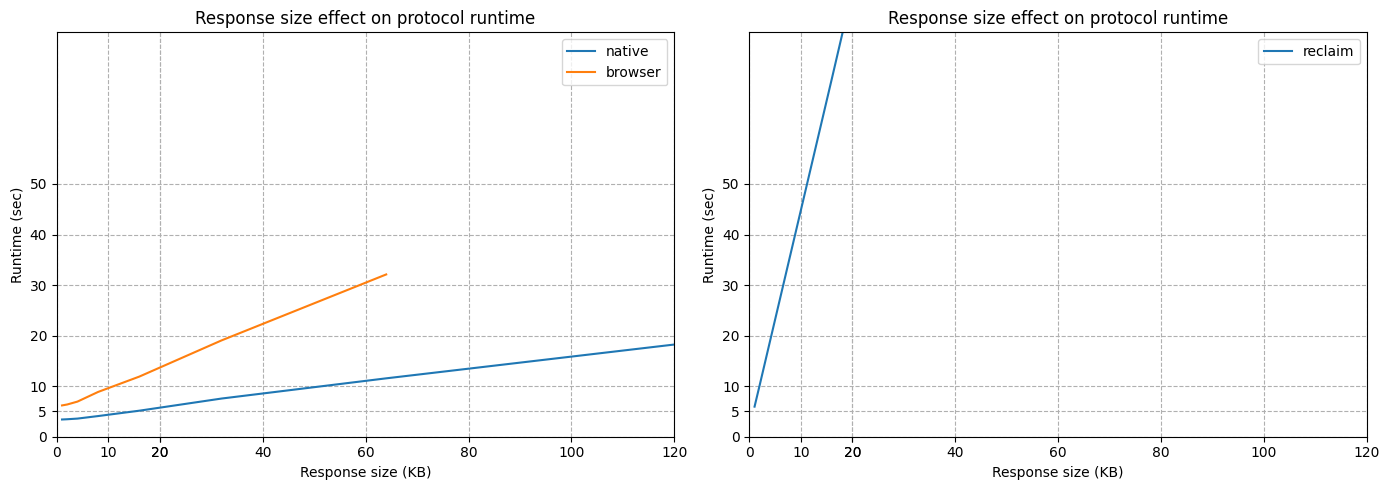

In [22]:
plt.style.use("default")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

df1_filter = df1[df1["group"] == "download_size"].copy()
df2_filter = df2[df2["group"] == "download_size"].copy()
df3_filter = df_reclaim[df_reclaim["group"] == "download_size"].copy()

agg1 = df1_filter.groupby("download_size")["time_total"].mean().reset_index()
agg2 = df2_filter.groupby("download_size")["time_total"].mean().reset_index()
agg3 = df3_filter.groupby("response_size(B)")["runtime(ms)"].mean().reset_index()

ax1.plot(agg1["download_size"]/1024.0, agg1["time_total"]/1000.0, label="native")
ax1.plot(agg2["download_size"]/1024.0, agg2["time_total"]/1000.0, label="browser")
ax2.plot(agg3["response_size(B)"]/1024.0, agg3["runtime(ms)"]/1000.0, label="reclaim")

ax1.set_ylim(0, 13)
ax2.set_ylim(15, 25)

for ax in [ax1, ax2]:
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    ax.set_xlabel("Response size (KB)")
    ax.set_ylabel("Runtime (sec)")
    ax.set_title("Response size effect on protocol runtime")
    ax.legend(loc="upper right")
    ax.set_xticks(list(range(0, 30, 10)) + list(range(20,140, 20)) )
    ax.set_yticks(list(range(0, 10, 5)) + list(range(10, 60, 10)))
    ax.grid(True, linestyle="--")

plt.tight_layout()
plt.savefig("response_size.svg", bbox_inches="tight")
plt.show()